In [ ]:
import pandas as pd
df_csv=pd.read_csv("complete_dataset_with_all_features.csv")
print(df_csv.head())


                     keyword                                        title  \
0            air fryer India               Nike air fryer India Model 114   
1  microwave oven convection  Philips microwave oven convection Model 363   
2            air fryer India               Dell air fryer India Model 406   
3   power bank fast charging      Nike power bank fast charging Model 363   
4          men running shoes          Samsung men running shoes Model 836   

   price  rating  reviews          platform       delivery    brand  \
0  509.0     3.8     3324  reliance digital         2 days     Nike   
1  545.0     4.5     3336  reliance digital         2 days  Philips   
2  580.0     5.0     4288  reliance digital  free delivery     Dell   
3  702.0     4.5     1477          flipkart         2 days     Nike   
4  712.0     4.6      819          flipkart         2 days  Samsung   

  price_range  popularity_score  raw_price  discount  
0  low-Budget         30.815055      509.0         0  


### 1. Total products available per keyword

,Keyword,Product Count
0,microwave oven convection,261
1,men running shoes,242
2,air fryer India,240
3,power bank fast charging,238
4,office chair ergonomic,235
5,speakers,120
6,smartwatch,120
7,Washing Machines,119
8,Smart Phones,119
9,Laptop,119


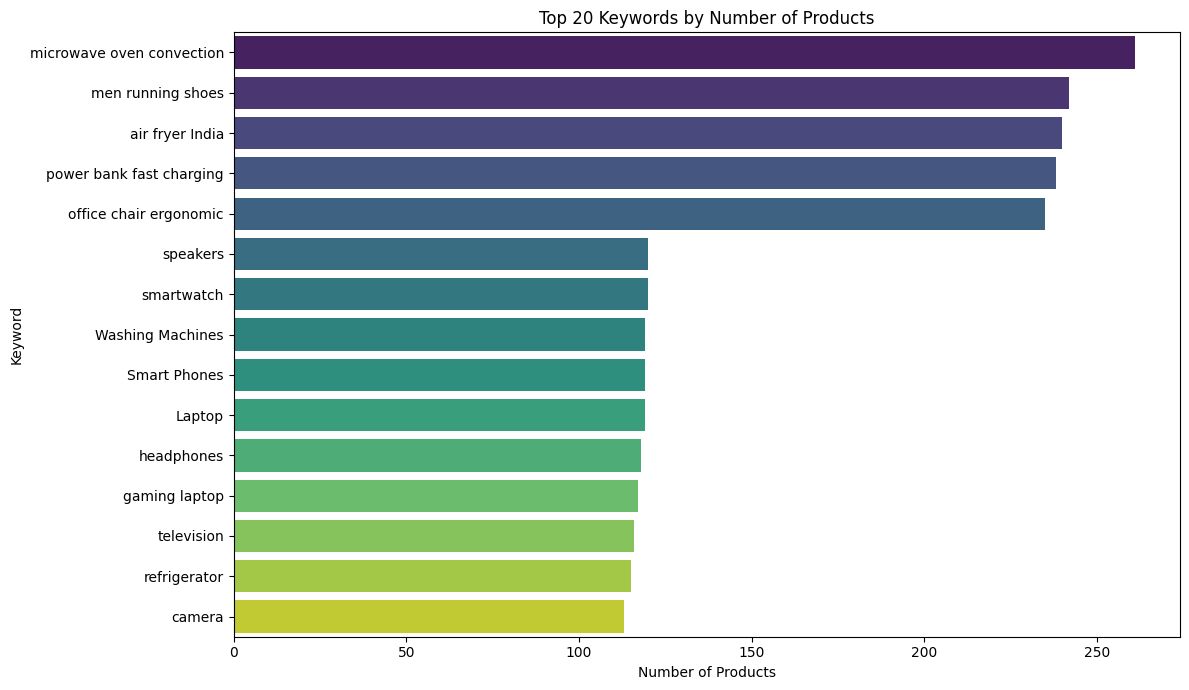

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count of products per keyword
products_per_keyword = df_csv['keyword'].value_counts().reset_index()
products_per_keyword.columns = ['Keyword', 'Product Count']

# Display the top 10 keywords by product count
display(products_per_keyword.head(10))

# Plotting the distribution of products per keyword (top 20 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Count', y='Keyword', hue='Keyword', data=products_per_keyword.head(20), palette='viridis', legend=False)
plt.title('Top 20 Keywords by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

### 2. Overall average price of products

In [ ]:
# Calculate the overall average price
average_price = df_csv['price'].mean()
print(f"The overall average price of products is: {average_price:.2f}")

The overall average price of products is: 16639.26


### 3. Distribution of price across all products

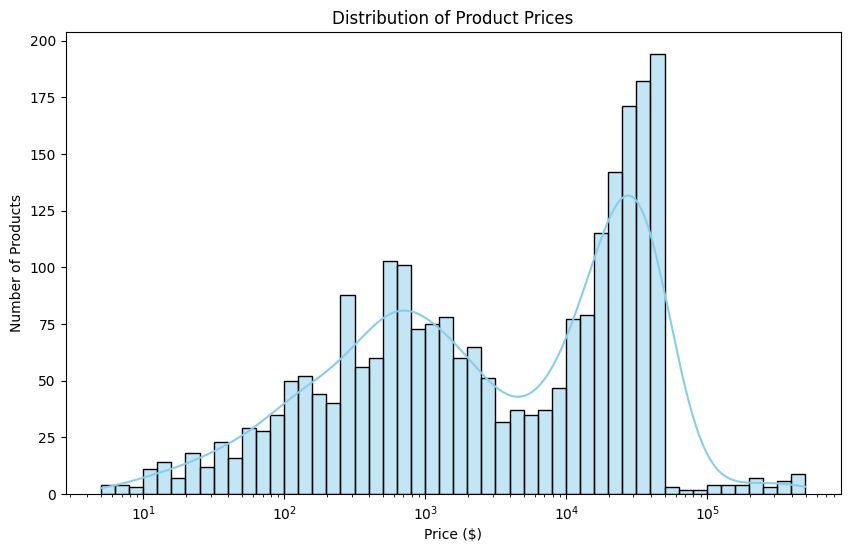

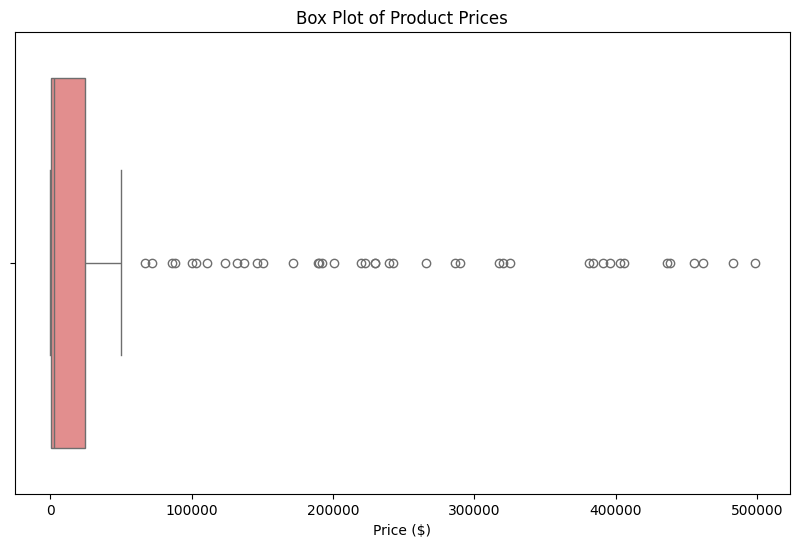

In [ ]:
# Plotting the distribution of price
plt.figure(figsize=(10, 6))
sns.histplot(df_csv['price'], bins=50, log_scale=True ,kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_csv['price'], color='lightcoral')
plt.title('Box Plot of Product Prices')
plt.xlabel('Price ($)')
plt.show()

### 4. Average rating across all products

In [ ]:
# Calculate the overall average rating
average_rating = df_csv['rating'].mean()
print(f"The overall average rating across all products is: {average_rating:.2f}")

The overall average rating across all products is: 4.08


### 5. Distribution of reviews (low vs high engagement products)

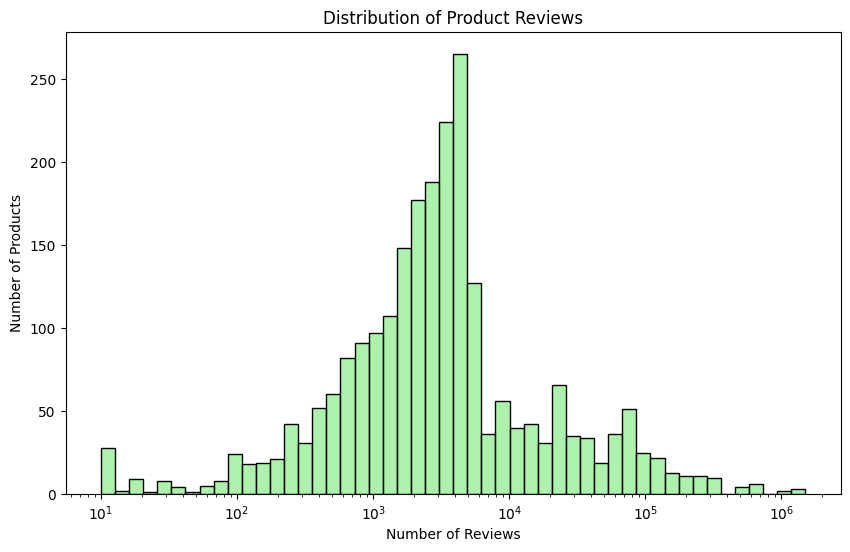

Review Quantiles:
0.25    1160.0
0.50    2964.0
0.75    6100.0
Name: reviews, dtype: float64

Number of products with very high engagement (>= 35000 reviews): 242


In [ ]:
# Plotting the distribution of reviews
plt.figure(figsize=(10, 6))
sns.histplot(df_csv['reviews'], bins=50,log_scale=True, color='lightgreen', stat='count')
plt.title('Distribution of Product Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Products')
plt.show()

# To further understand low vs high engagement, we can look at percentiles
review_quantiles = df_csv['reviews'].quantile([0.25, 0.5, 0.75])
print("Review Quantiles:")
print(review_quantiles)

# Example: products with very high engagement (e.g., top 10% of reviews)
high_engagement_threshold = df_csv['reviews'].quantile(0.90)
high_engagement_products = df_csv[df_csv['reviews'] >= high_engagement_threshold]
print(f"\nNumber of products with very high engagement (>= {high_engagement_threshold:.0f} reviews): {len(high_engagement_products)}")

## Brand Analysis

### Which brand appears most frequently?

Top 10 Most Frequent Brands:


,Brand,Count
0,Unknown,465
1,Samsung,251
2,HP,204
3,LG,197
4,Dell,155
5,Sony,154
6,Philips,141
7,Nike,134
8,Puma,134
9,Boat,134


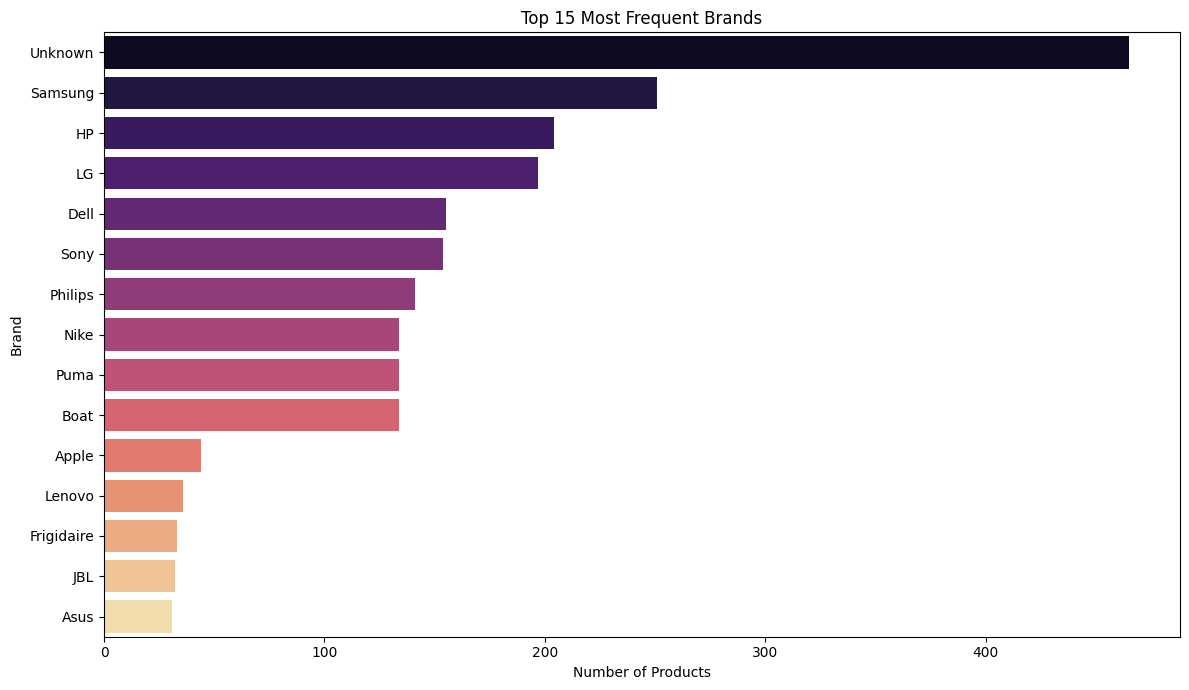

In [ ]:
# Calculate brand frequency
brand_frequency = df_csv['brand'].value_counts().reset_index()
brand_frequency.columns = ['Brand', 'Count']

# Display the top 10 most frequent brands
print("Top 10 Most Frequent Brands:")
display(brand_frequency.head(10))

# Plotting brand frequency
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Brand', hue='Brand', data=brand_frequency.head(15), palette='magma', legend=False)
plt.title('Top 15 Most Frequent Brands')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### Which brand has the highest average visibility_score?

Top 10 Brands by Average Popularity Score:


,Brand,Average Popularity Score
1,Apple,45.599737
5,Bose,43.675939
15,JBL,42.918197
6,Canon,40.697509
32,Whirlpool,40.400081
13,Hotpoint,40.368550
21,Nikon,40.120874
10,Google,40.082380
8,Frigidaire,39.658686
9,GE,37.984905


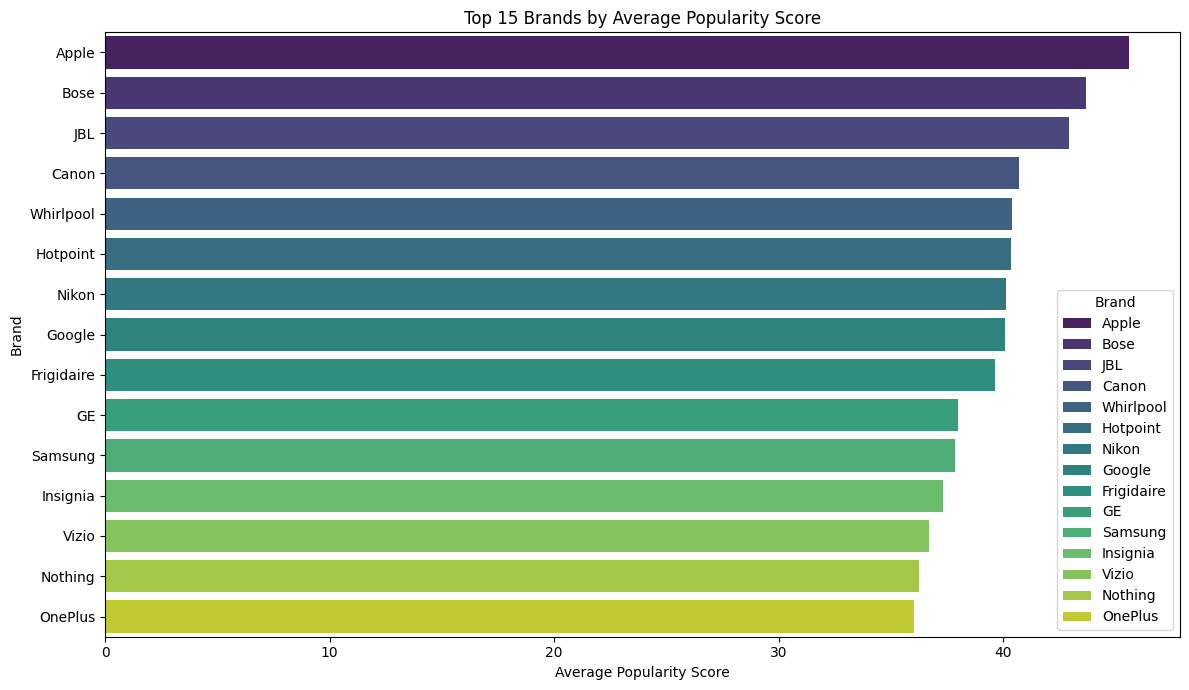

In [ ]:
# Calculate average popularity_score per brand (using popularity_score as a proxy for visibility_score)
average_popularity_score_by_brand = df_csv.groupby('brand')['popularity_score'].mean().reset_index()
average_popularity_score_by_brand.columns = ['Brand', 'Average Popularity Score']

# Sort and display top 10 brands by average popularity score
average_popularity_score_by_brand = average_popularity_score_by_brand.sort_values(by='Average Popularity Score', ascending=False)
print("Top 10 Brands by Average Popularity Score:")
display(average_popularity_score_by_brand.head(10))

# Plotting average popularity score by brand (top 15 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average Popularity Score', y='Brand', hue='Brand', data=average_popularity_score_by_brand.head(15), palette='viridis', legend=True)
plt.title('Top 15 Brands by Average Popularity Score')
plt.xlabel('Average Popularity Score')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### What is the average rating per brand? Which brands have the highest average rating?

Top 10 Brands by Average Rating:


,Brand,Average Rating
21,Nikon,4.766667
18,Microsoft,4.700000
6,Canon,4.685714
22,Nothing,4.640000
15,JBL,4.596250
1,Apple,4.588636
2,Asus,4.534194
17,Lenovo,4.504444
23,OnePlus,4.500000
5,Bose,4.488000


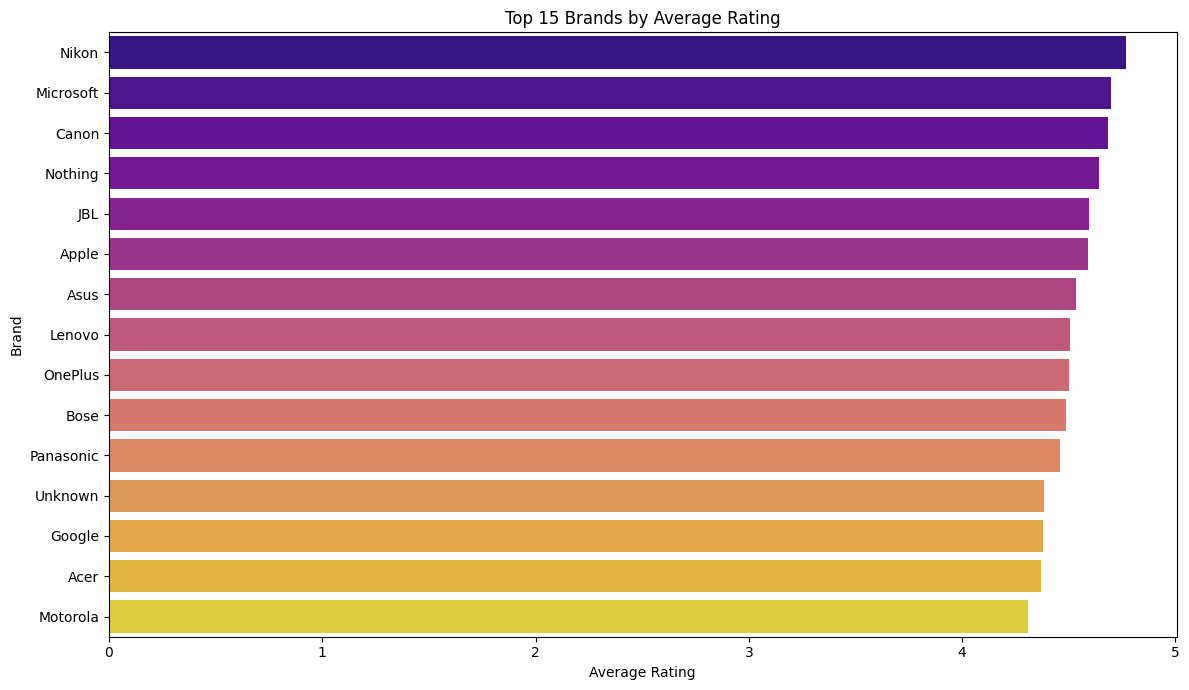

In [ ]:
# Calculate average rating per brand
average_rating_by_brand = df_csv.groupby('brand')['rating'].mean().reset_index()
average_rating_by_brand.columns = ['Brand', 'Average Rating']

# Sort and display top 10 brands by average rating
average_rating_by_brand = average_rating_by_brand.sort_values(by='Average Rating', ascending=False)
print("Top 10 Brands by Average Rating:")
display(average_rating_by_brand.head(10))

# Plotting average rating by brand (top 15 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average Rating', y='Brand', hue='Brand', data=average_rating_by_brand.head(15), palette='plasma', legend=False)
plt.title('Top 15 Brands by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### Which brands appear most in top ratings (e.g., rating >= 4.5)?

Top 10 Brands Appearing Most in Top-Rated Products (Rating >= 4.5):


,Brand,Count
0,Unknown,245
1,Samsung,90
2,Sony,65
3,HP,56
4,LG,55
5,Apple,35
6,Dell,33
7,Puma,28
8,JBL,28
9,Canon,28


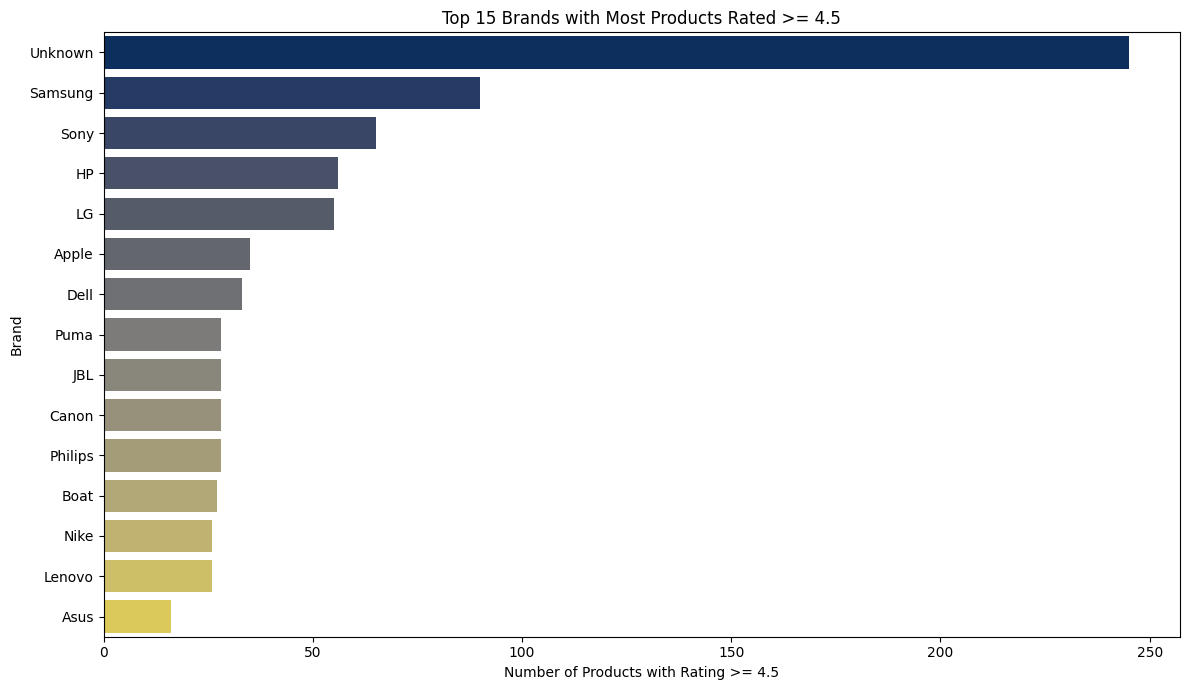

In [ ]:
# Filter for products with high ratings (e.g., rating >= 4.5)
top_rated_products = df_csv[df_csv['rating'] >= 4.5]

# Count brand occurrences in top-rated products
top_rated_brand_frequency = top_rated_products['brand'].value_counts().reset_index()
top_rated_brand_frequency.columns = ['Brand', 'Count']

# Display the top 10 brands appearing most in top ratings
print("Top 10 Brands Appearing Most in Top-Rated Products (Rating >= 4.5):")
display(top_rated_brand_frequency.head(10))

# Plotting brands in top ratings (top 15 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Brand', hue='Brand', data=top_rated_brand_frequency.head(15), palette='cividis', legend=False)
plt.title('Top 15 Brands with Most Products Rated >= 4.5')
plt.xlabel('Number of Products with Rating >= 4.5')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

## Pricing Analysis

### 1. What is the price distribution across different brands?

/tmp/ipykernel_1799/2791703378.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='brand', data=df_top_brands.sort_values('price', ascending=False), palette='viridis')


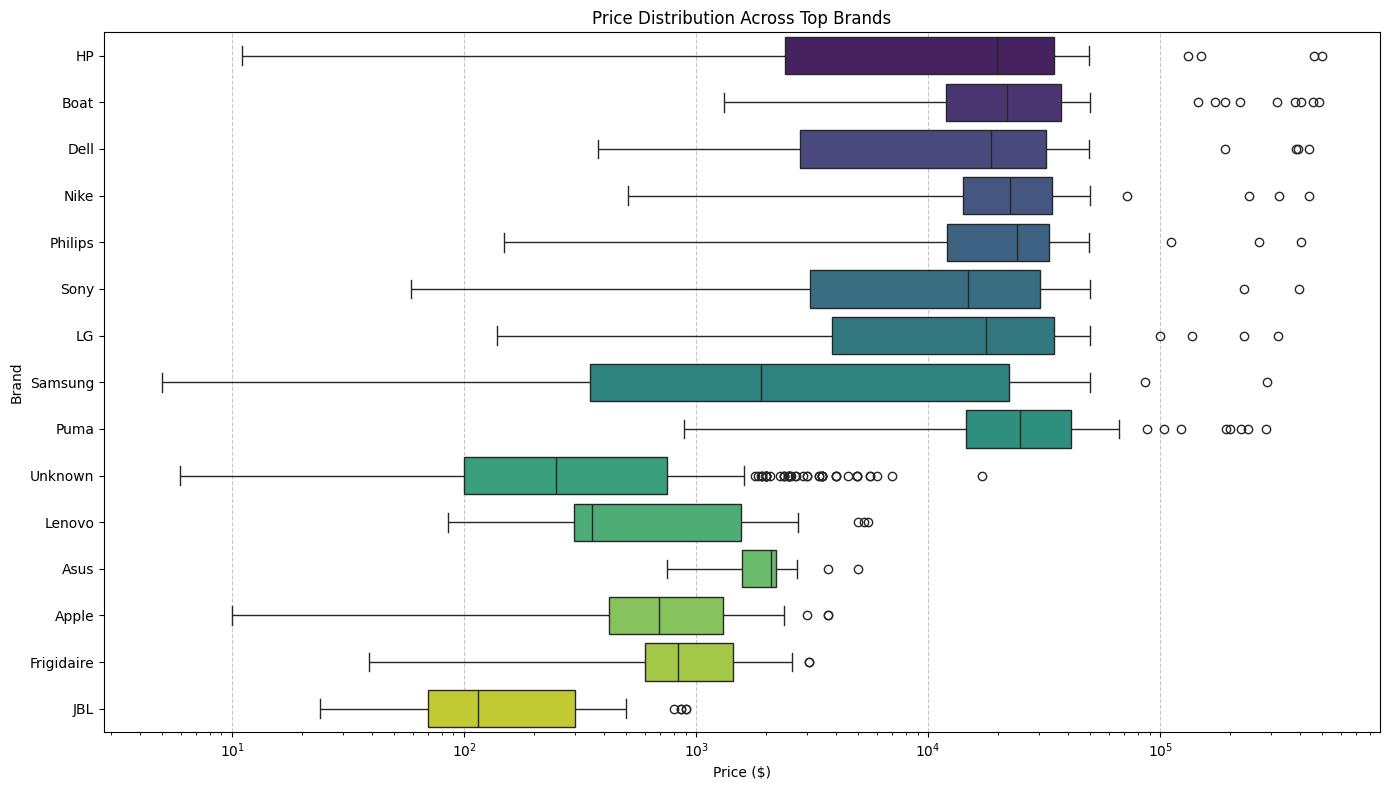

/tmp/ipykernel_1799/2791703378.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='price', y='brand', data=df_top_brands.sort_values('price', ascending=False), palette='plasma')


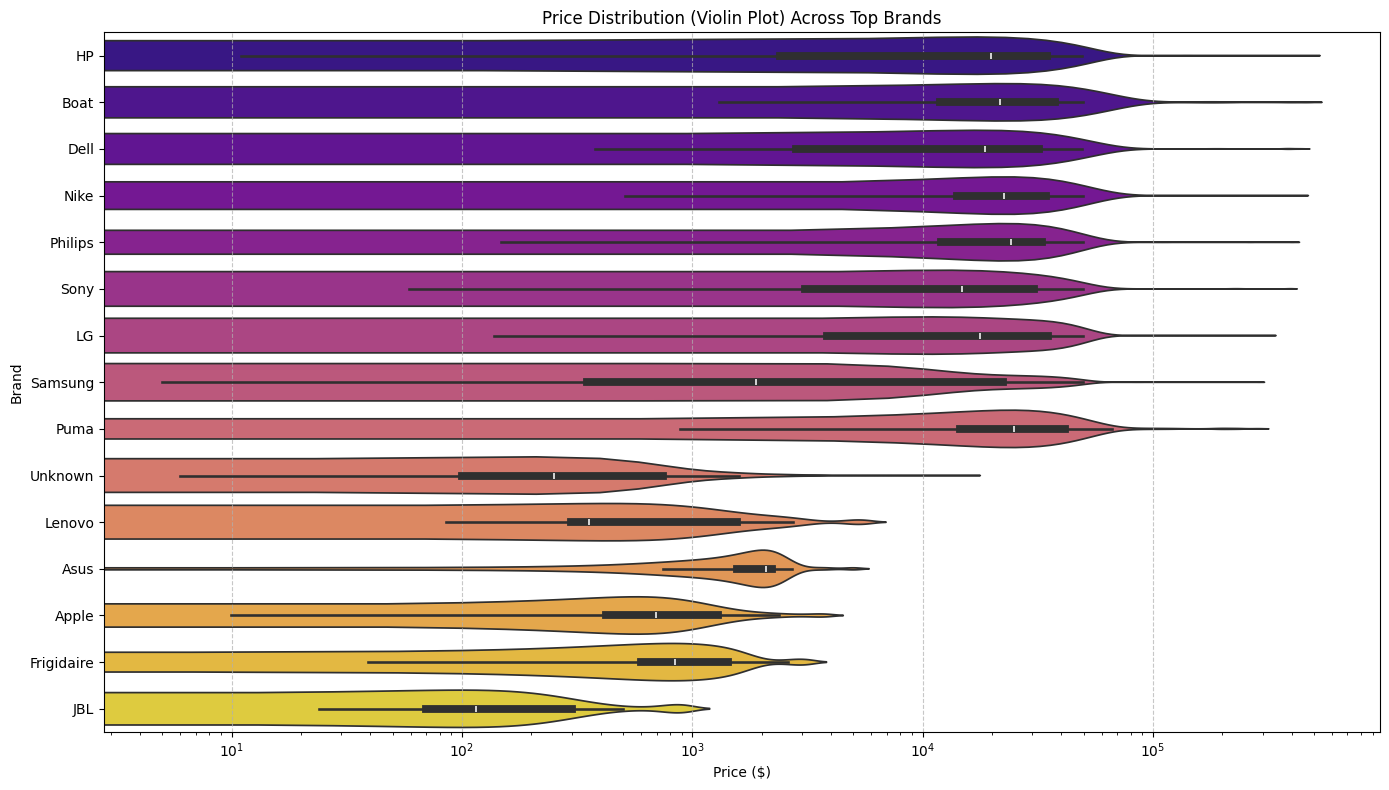

In [ ]:
# To avoid plotting too many brands, we'll consider the top N brands by product count
top_brands = df_csv['brand'].value_counts().nlargest(15).index

# Filter the DataFrame to include only these top brands
df_top_brands = df_csv[df_csv['brand'].isin(top_brands)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='price', y='brand', data=df_top_brands.sort_values('price', ascending=False), palette='viridis')
plt.title('Price Distribution Across Top Brands')
plt.xlabel('Price ($)')
plt.ylabel('Brand')
plt.xscale('log') # Use log scale for price if there's a wide range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.violinplot(x='price', y='brand', data=df_top_brands.sort_values('price', ascending=False), palette='plasma')
plt.title('Price Distribution (Violin Plot) Across Top Brands')
plt.xlabel('Price ($)')
plt.ylabel('Brand')
plt.xscale('log') # Use log scale for price if there's a wide range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. How are products distributed across `price_range` categories?

Product Distribution Across Price Range Categories:


,Price Range,Product Count
0,low-Budget,1271
1,Premium,819
2,Mid-Range,261
3,Luxury,41


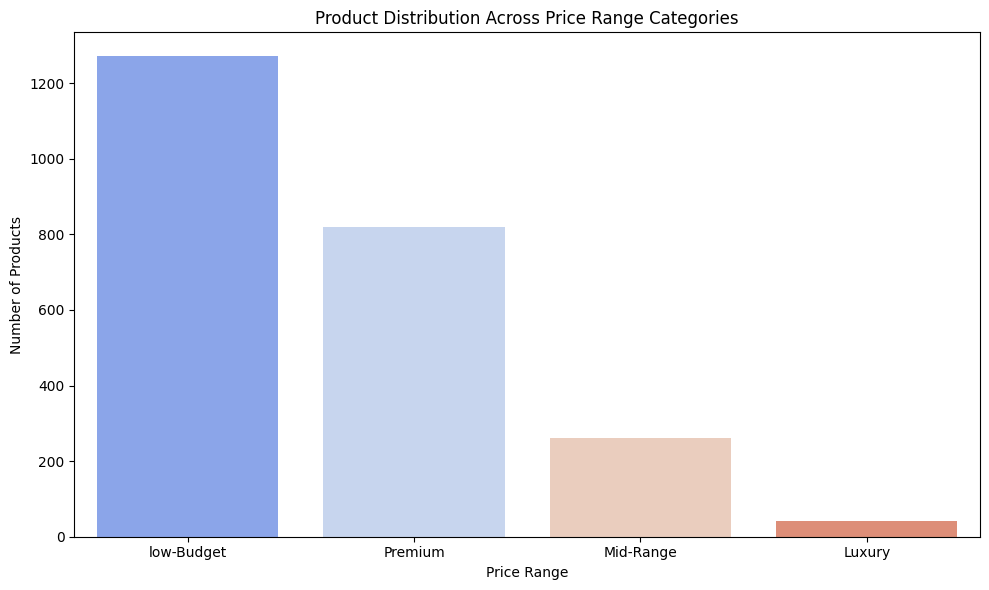

In [ ]:
# Calculate the distribution of products across price_range categories
price_range_distribution = df_csv['price_range'].value_counts().reset_index()
price_range_distribution.columns = ['Price Range', 'Product Count']

print("Product Distribution Across Price Range Categories:")
display(price_range_distribution)

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Price Range', y='Product Count', hue='Price Range', data=price_range_distribution, palette='coolwarm', legend=False)
plt.title('Product Distribution Across Price Range Categories')
plt.xlabel('Price Range')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

### 3. Do higher-priced products have better rankings (rating)?

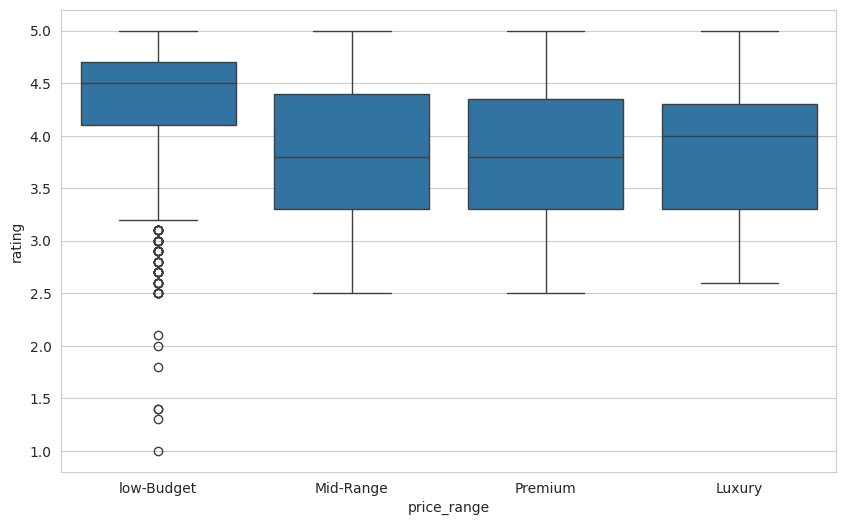

In [ ]:

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_csv,
    x='price_range',
    y='rating'
)

plt.show()

### 4. What is the average price per platform?

,Platform,Average Price
86,LG Parts,99999.000000
247,reliance digital,34996.246106
214,amazon,33868.276358
219,croma,30032.816054
234,flipkart,28100.969965
84,Kelly's Home Center,8932.490000
27,Big Chill,5995.000000
155,The Camera Exchange,5599.000000
7,Aden Camera,4573.300000
29,Bloom Audio,4500.000000


/tmp/ipykernel_1799/2977165039.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


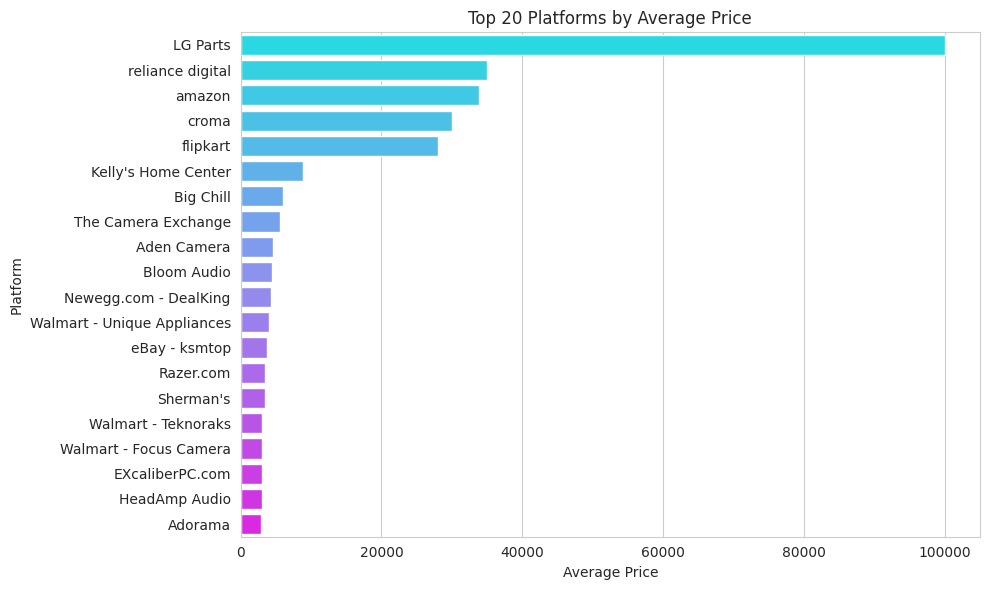

In [ ]:
average_price_per_platform = (
    df_csv.groupby('platform')['price']
    .mean()
    .reset_index()
)
#display(average_price_per_platform)
average_price_per_platform.columns = ['Platform', 'Average Price']

top20 = average_price_per_platform.sort_values(
    by='Average Price',
    ascending=False
).head(20)
display(top20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20,
    x='Average Price',
    y='Platform',
    palette='cool'
)

plt.title('Top 20 Platforms by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 5. Which products have the highest price within each keyword?

In [ ]:
# Find the product with the highest price within each keyword
highest_priced_per_keyword = df_csv.loc[df_csv.groupby('keyword')['price'].idxmax()]

print("Products with the Highest Price within Each Keyword (Top 20):")
display(highest_priced_per_keyword[['keyword', 'title', 'brand', 'price']].sort_values(by='price', ascending=False).head(20))

Products with the Highest Price within Each Keyword (Top 20):


,keyword,title,brand,price
1215,men running shoes,HP men running shoes Model 483,HP,498050.00
1214,microwave oven convection,Boat microwave oven convection Model 424,Boat,482890.00
1212,office chair ergonomic,Boat office chair ergonomic Model 324,Boat,455330.00
1210,power bank fast charging,Nike power bank fast charging Model 406,Nike,436130.00
1201,air fryer India,Boat air fryer India Model 822,Boat,317150.00
1856,refrigerator,LG LTC24380ST 24.0 cu. ft. Top Freezer Refrige...,LG,99999.00
1930,gaming laptop,"Razer Blade 18 18"" GeForce RTX 5090 Laptop GPU...",Unknown,6999.99
2286,camera,Fujifilm GFX100RF Digital Camera,Unknown,5599.00
2182,speakers,Bowers & Wilkins 702 S3 Signature Floorstandin...,Unknown,4950.00
1685,headphones,Audeze LCD-5 Open-Back Planar Magnetic Headphones,Unknown,4500.00


## Discount & Offer Analysis

### 1. What percentage of products have a non-zero discount?

In [ ]:
# Calculate the number of products with a non-zero discount
non_zero_discount_count = df_csv[df_csv['discount'] > 0].shape[0]

# Calculate the total number of products
total_products = df_csv.shape[0]

# Calculate the percentage
percentage_discounted = (non_zero_discount_count / total_products) * 100

print(f"Percentage of products with a non-zero discount: {percentage_discounted:.2f}%")

Percentage of products with a non-zero discount: 0.00%


### 2. Do discounted products have better rankings (rating)?

Average rating for discounted products: nan
Average rating for non-discounted products: 4.08


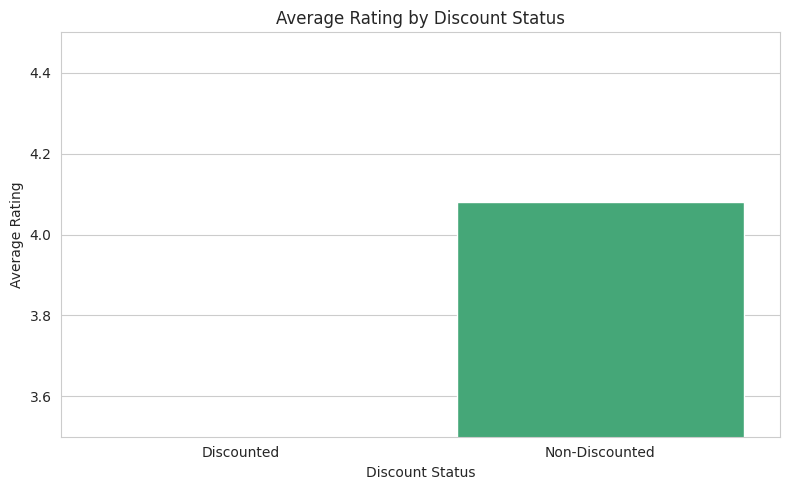

In [ ]:
# Separate products into discounted and non-discounted groups
discounted_products = df_csv[df_csv['discount'] > 0]
non_discounted_products = df_csv[df_csv['discount'] == 0]

# Calculate average rating for each group
avg_rating_discounted = discounted_products['rating'].mean()
avg_rating_non_discounted = non_discounted_products['rating'].mean()

print(f"Average rating for discounted products: {avg_rating_discounted:.2f}")
print(f"Average rating for non-discounted products: {avg_rating_non_discounted:.2f}")

# Prepare data for bar plot
rating_comparison_df = pd.DataFrame({
    'Discount Status': ['Discounted', 'Non-Discounted'],
    'Average Rating': [avg_rating_discounted, avg_rating_non_discounted]
})

# Visualize the average rating for both groups using a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Discount Status', y='Average Rating', hue='Discount Status', data=rating_comparison_df, palette='viridis', legend=False)
plt.title('Average Rating by Discount Status')
plt.xlabel('Discount Status')
plt.ylabel('Average Rating')
plt.ylim(3.5, 4.5) # Set a reasonable y-limit for better comparison
plt.tight_layout()
plt.show()

### 3. Which brand offers the highest average discount?

Top 10 Brands by Average Discount:


,brand,discount
0,Acer,0.0
1,Apple,0.0
2,Asus,0.0
3,Boat,0.0
4,Bosch,0.0
5,Bose,0.0
6,Canon,0.0
7,Dell,0.0
8,Frigidaire,0.0
9,GE,0.0


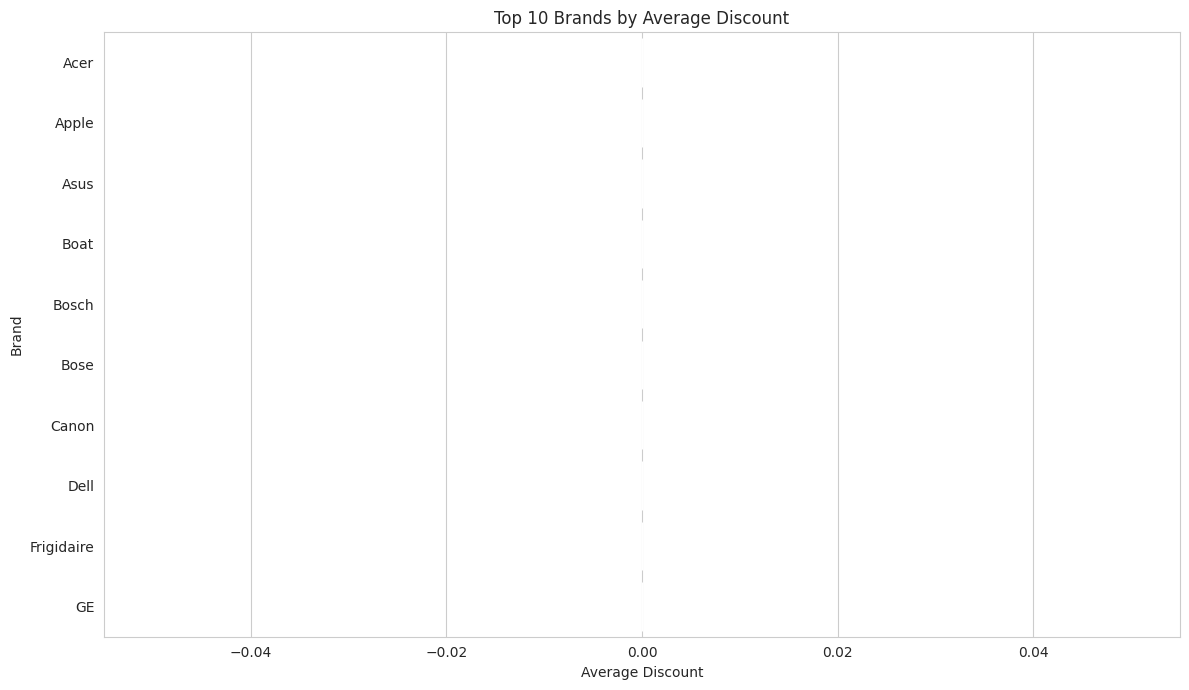

In [ ]:
# Calculate the average discount per brand
avg_discount_by_brand = df_csv.groupby('brand')['discount'].mean().reset_index()

# Sort and display the top 10 brands by average discount
avg_discount_by_brand = avg_discount_by_brand.sort_values(by='discount', ascending=False)
print("Top 10 Brands by Average Discount:")
display(avg_discount_by_brand.head(10))

# Plotting the top 10 brands by average discount
plt.figure(figsize=(12, 7))
sns.barplot(x='discount', y='brand', hue='brand', data=avg_discount_by_brand.head(10), palette='viridis', legend=False)
plt.title('Top 10 Brands by Average Discount')
plt.xlabel('Average Discount')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### 4. Which platform provides the highest average discount?

Top 10 Platforms by Average Discount:


,platform,discount
0,A5 IT,0.0
1,ABC Warehouse,0.0
2,AT&T,0.0
3,Abt Electronics & Appliances,0.0
4,Academy Sports + Outdoors,0.0
5,Ace Family Hardware,0.0
6,Ace Hardware,0.0
7,Aden Camera,0.0
8,Adorama,0.0
9,Aggressive Appliances,0.0


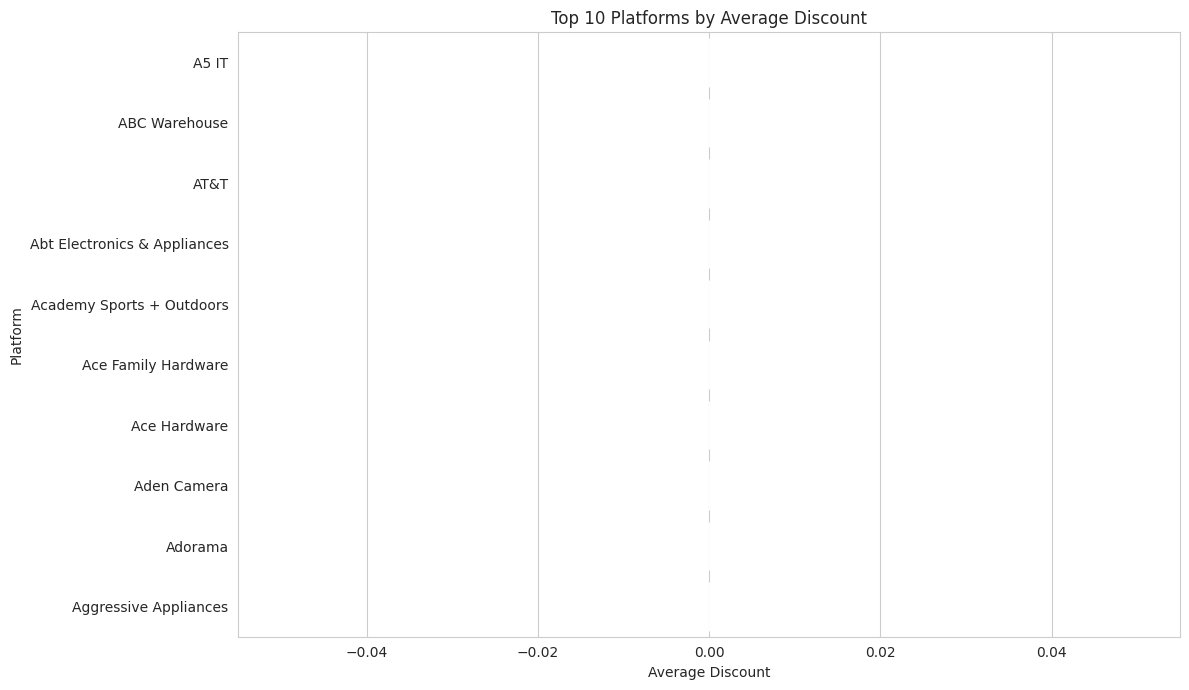

In [ ]:
# Calculate the average discount per platform
avg_discount_by_platform = df_csv.groupby('platform')['discount'].mean().reset_index()

# Sort and display the top 10 platforms by average discount
avg_discount_by_platform = avg_discount_by_platform.sort_values(by='discount', ascending=False)
print("Top 10 Platforms by Average Discount:")
display(avg_discount_by_platform.head(10))

# Plotting the top 10 platforms by average discount
plt.figure(figsize=(12, 7))
sns.barplot(x='discount', y='platform', hue='platform', data=avg_discount_by_platform.head(10), palette='plasma', legend=False)
plt.title('Top 10 Platforms by Average Discount')
plt.xlabel('Average Discount')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 5. Is there a relationship between discount and rating?

Correlation between Discount and Rating: nan


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


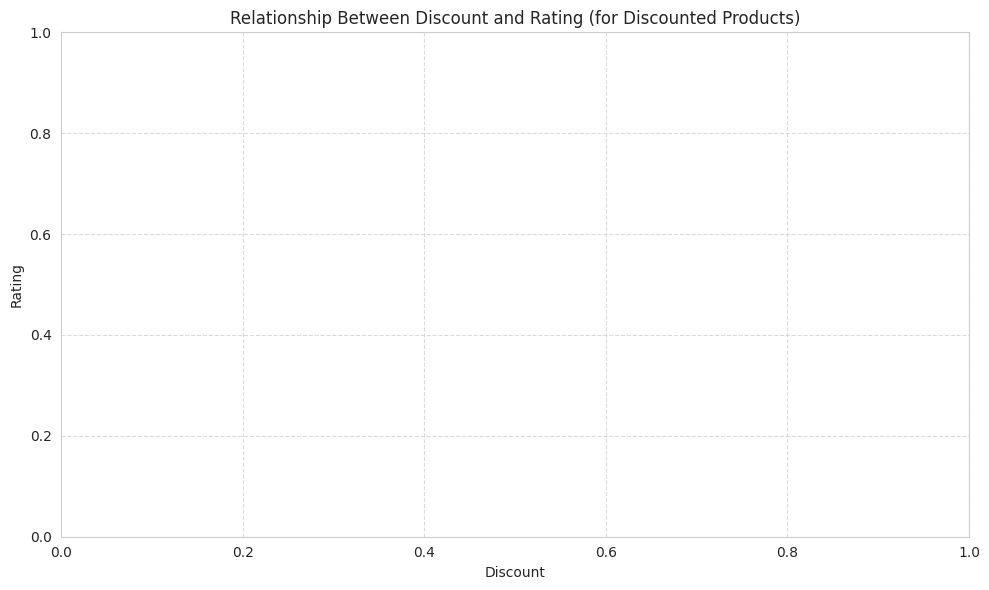

In [ ]:
# Calculate the correlation between discount and rating
correlation_discount_rating = df_csv['discount'].corr(df_csv['rating'])
print(f"Correlation between Discount and Rating: {correlation_discount_rating:.2f}")

# Visualize the relationship using a scatter plot (only for products with discount > 0 for better visibility)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='discount', y='rating', data=df_csv[df_csv['discount'] > 0], alpha=0.6, color='purple')
plt.title('Relationship Between Discount and Rating (for Discounted Products)')
plt.xlabel('Discount')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Platform Analysis

### 1. Which platform lists the highest number of products?

Top 10 Platforms by Product Count:


,Platform,Product Count
0,reliance digital,321
1,amazon,313
2,croma,299
3,flipkart,283
4,Best Buy,240
5,Walmart,96
6,Home Depot,48
7,Target,48
8,Lowe's,30
9,B&H Photo-Video-Audio,23


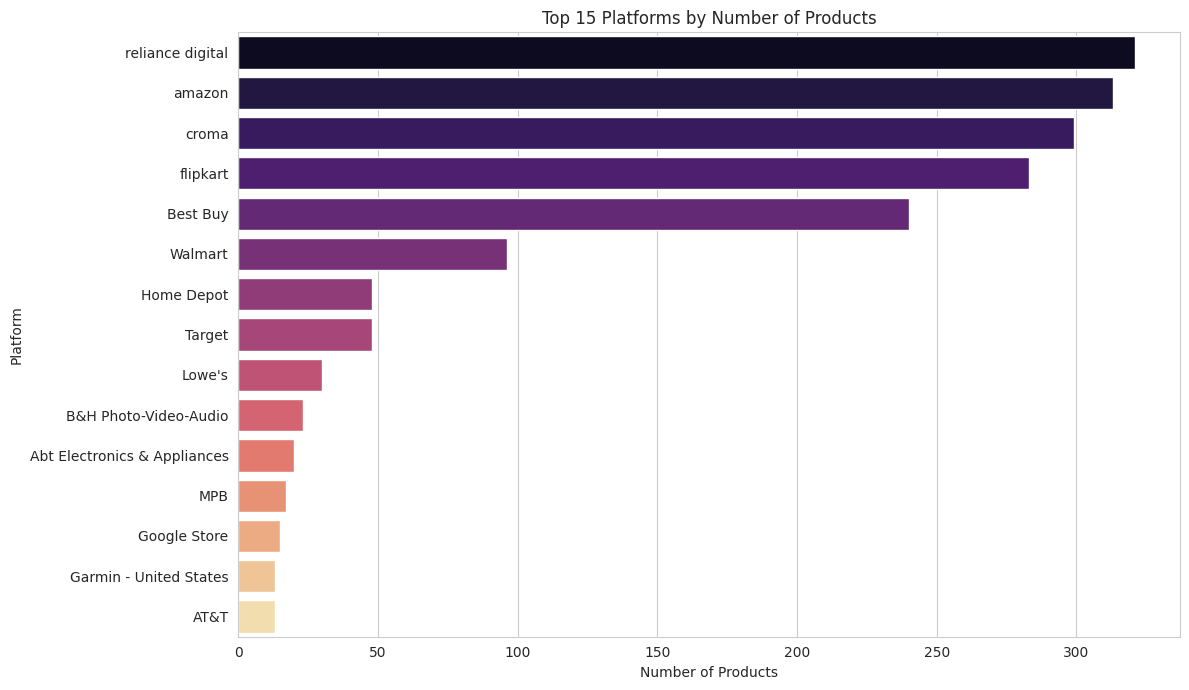

In [ ]:
# Calculate the count of products per platform
products_per_platform = df_csv['platform'].value_counts().reset_index()
products_per_platform.columns = ['Platform', 'Product Count']

# Display the top 10 platforms by product count
print("Top 10 Platforms by Product Count:")
display(products_per_platform.head(10))

# Plotting the distribution of products per platform (top 15 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Count', y='Platform', hue='Platform', data=products_per_platform.head(15), palette='magma', legend=False)
plt.title('Top 15 Platforms by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 2. Which platform has the highest average rating?

Top 25 Platforms by Average Rating:


,Platform,Average Rating
4,Academy Sports + Outdoors,5.000000
10,Albo Appliance,5.000000
53,DirectDial,5.000000
103,Newegg.com - Apollo Premium Electronics,5.000000
86,LG Parts,5.000000
73,Halvorson Company,5.000000
115,Overseas Electronics,5.000000
74,Hartville Hardware,5.000000
226,eBay - eyoun53,5.000000
148,Successories,5.000000


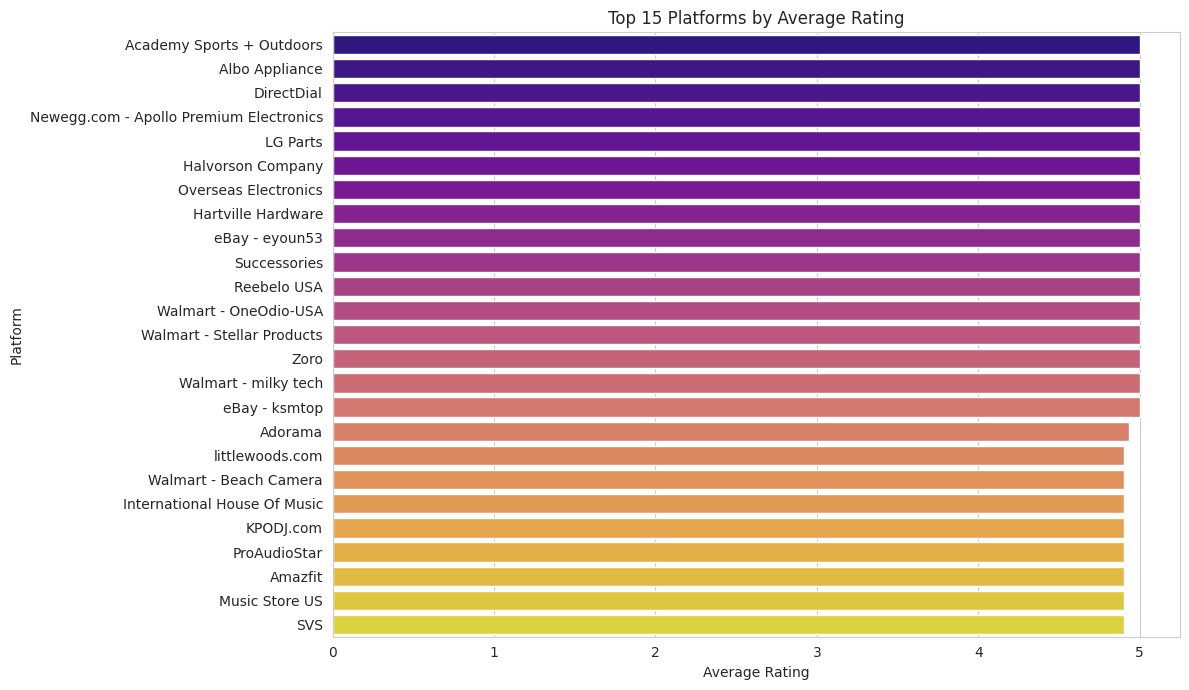

In [ ]:
# Calculate the average rating per platform
avg_rating_by_platform = df_csv.groupby('platform')['rating'].mean().reset_index()
avg_rating_by_platform.columns = ['Platform', 'Average Rating']

# Sort and display the top 25 platforms by average rating
avg_rating_by_platform = avg_rating_by_platform.sort_values(by='Average Rating', ascending=False)
print("Top 25 Platforms by Average Rating:")
display(avg_rating_by_platform.head(25))

# Plotting average rating by platform (top 25 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average Rating', y='Platform', hue='Platform', data=avg_rating_by_platform.head(25), palette='plasma', legend=False)
plt.title('Top 15 Platforms by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 3. Which platform has the lowest average price?

Platforms with the Lowest Average Price (Top 10):


,Platform,Average Price
201,Walmart - Wmkox8yii,6.790000
200,Walmart - WAIKAS Store,7.990000
180,Walmart - Jelly Comb,10.620000
250,staples.com,10.990000
207,Whatnot,12.000000
181,Walmart - KEEWONDA,13.950000
162,Verizon,14.751250
81,JLab,19.990000
2,AT&T,25.310769
169,Walmart - Cillso Store,26.990000


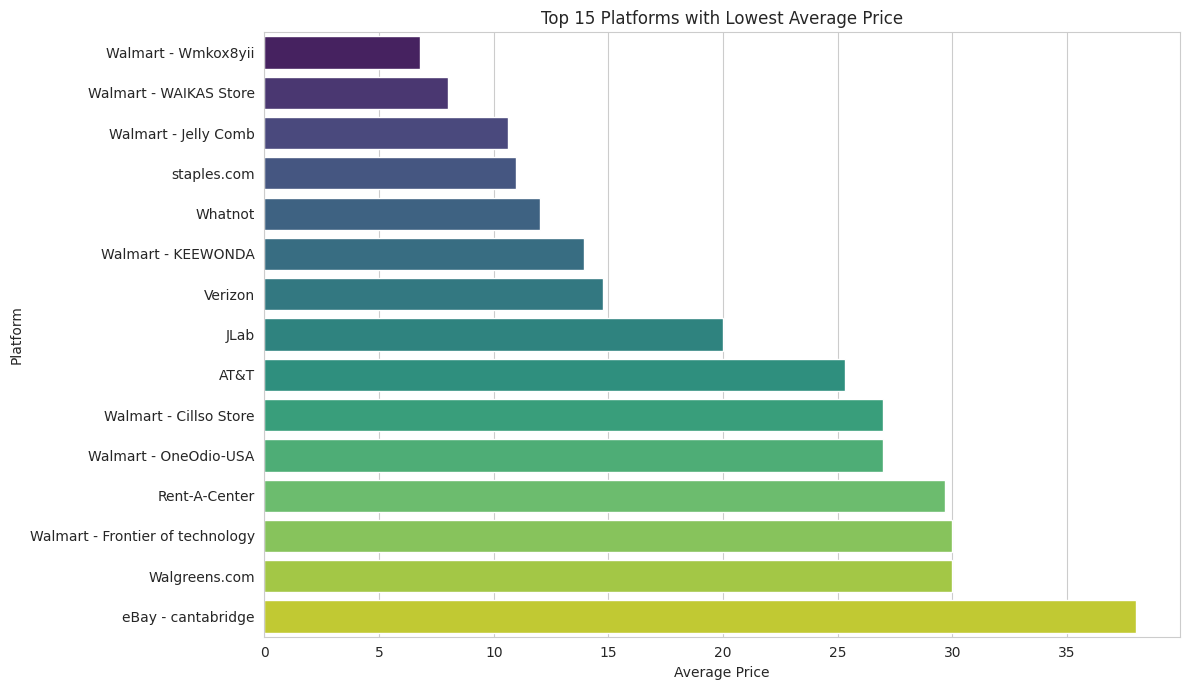

In [ ]:
# Calculate the average price per platform
avg_price_by_platform = df_csv.groupby('platform')['price'].mean().reset_index()
avg_price_by_platform.columns = ['Platform', 'Average Price']

# Sort and display the platforms with the lowest average price (bottom 10)
avg_price_by_platform = avg_price_by_platform.sort_values(by='Average Price', ascending=True)
print("Platforms with the Lowest Average Price (Top 10):")
display(avg_price_by_platform.head(10))

# Plotting platforms with the lowest average price (top 15 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average Price', y='Platform', hue='Platform', data=avg_price_by_platform.head(15), palette='viridis', legend=False)
plt.title('Top 15 Platforms with Lowest Average Price')
plt.xlabel('Average Price')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 4. What is the average rating (ranking) per platform?

In [ ]:
# This question is a duplicate of Question 2. Re-displaying the results for clarity.
# Calculate the average rating per platform
avg_rating_by_platform = df_csv.groupby('platform')['rating'].mean().reset_index()
avg_rating_by_platform.columns = ['Platform', 'Average Rating']

# Sort and display platforms by average rating
avg_rating_by_platform = avg_rating_by_platform.sort_values(by='Average Rating', ascending=False)
print("Average Rating Per Platform (Sorted by Highest Average Rating):")
display(avg_rating_by_platform.head(20)) # Display top 20 for a broader view

Average Rating Per Platform (Sorted by Highest Average Rating):


,Platform,Average Rating
4,Academy Sports + Outdoors,5.000000
10,Albo Appliance,5.000000
53,DirectDial,5.000000
103,Newegg.com - Apollo Premium Electronics,5.000000
86,LG Parts,5.000000
73,Halvorson Company,5.000000
115,Overseas Electronics,5.000000
74,Hartville Hardware,5.000000
226,eBay - eyoun53,5.000000
148,Successories,5.000000


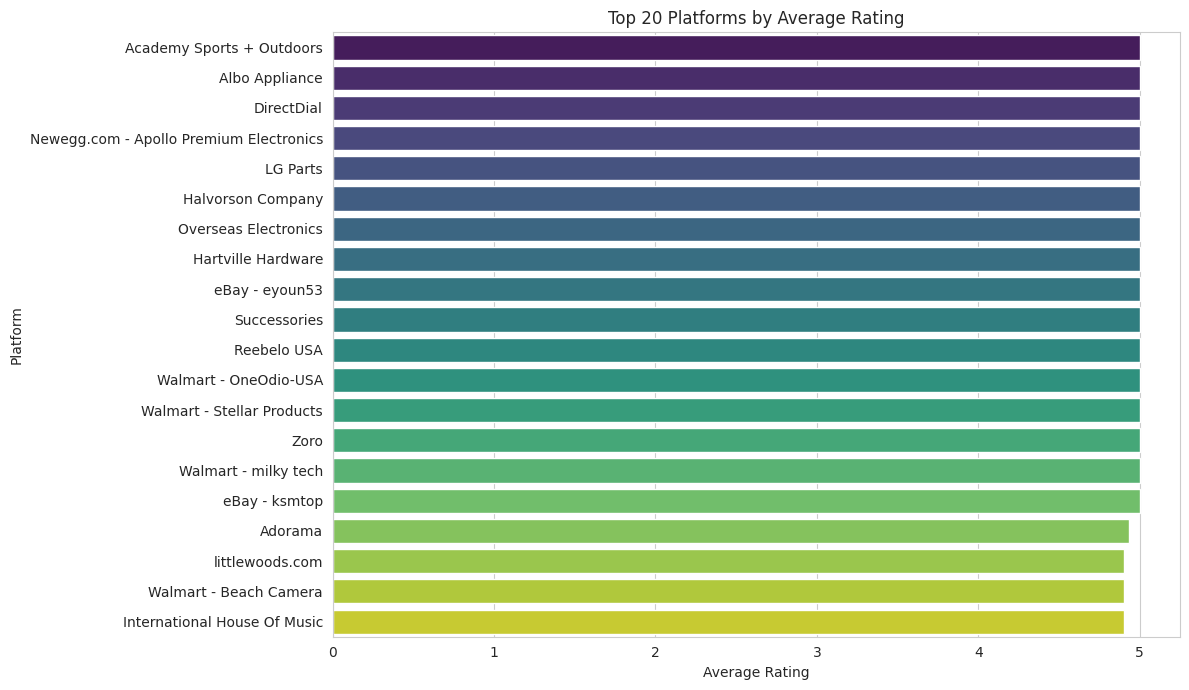

In [ ]:
# Plotting average rating per platform (top 20 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average Rating', y='Platform', hue='Platform', data=avg_rating_by_platform.head(20), palette='viridis', legend=False)
plt.title('Top 20 Platforms by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 5. Which brands are most frequently listed on each platform?

Most Frequently Listed Brand on Each Platform (Top 20 Platforms):


,platform,brand,Product Count
67,Best Buy,Unknown,69
410,reliance digital,LG,52
347,amazon,HP,45
360,croma,HP,41
384,flipkart,Dell,38
292,Walmart,Unknown,37
266,Target,Unknown,29
140,Home Depot,Unknown,23
125,Google Store,Google,15
123,Garmin - United States,Unknown,13


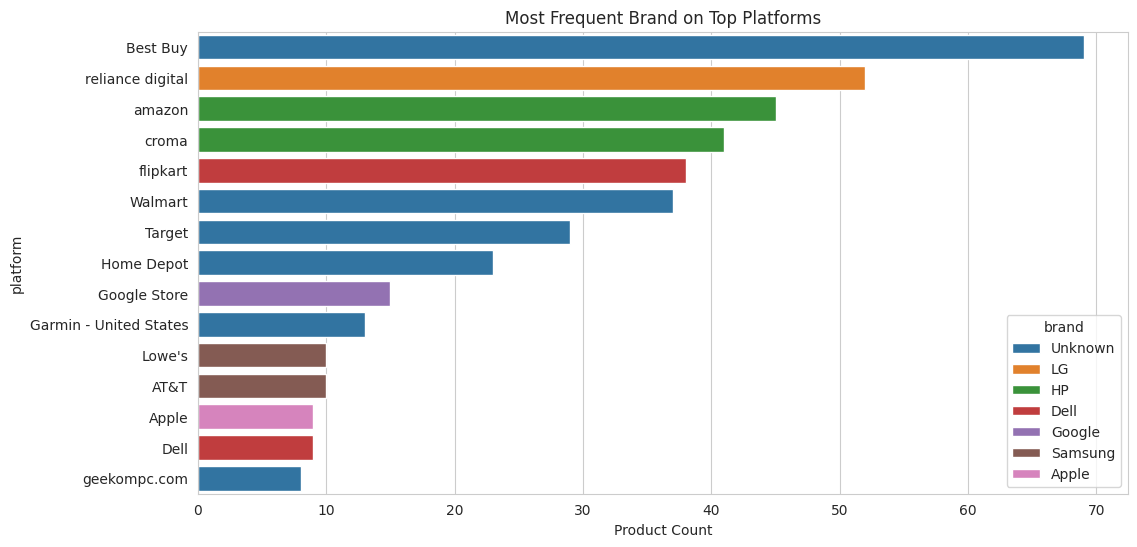

In [ ]:
# Group by platform and brand, then count products
platform_brand_counts = df_csv.groupby(['platform', 'brand']).size().reset_index(name='Product Count')

# Find the brand with the highest product count for each platform
idx = platform_brand_counts.groupby('platform')['Product Count'].idxmax()
most_frequent_brand_per_platform = platform_brand_counts.loc[idx]

# Sort by product count and display the top 20 platforms and their most frequent brand
most_frequent_brand_per_platform = most_frequent_brand_per_platform.sort_values(by='Product Count', ascending=False)
print("Most Frequently Listed Brand on Each Platform (Top 20 Platforms):")
display(most_frequent_brand_per_platform.head(20))

# Optionally, visualize for a select number of platforms (e.g., top 5 platforms by total products)
# For a more detailed visualization per platform, it would require iterating or more complex plotting.

# Get top 5 platforms by total product count
# top_5_platforms = df_csv['platform'].value_counts().nlargest(5).index
# df_top_5_platforms = df_csv[df_csv['platform'].isin(top_5_platforms)]

# plt.figure(figsize=(15, 10))
# sns.countplot(y='brand', hue='platform', data=df_top_5_platforms, order=df_top_5_platforms['brand'].value_counts().index[:15], palette='tab10')
# plt.title('Top 15 Brands on Top 5 Platforms')
# plt.xlabel('Number of Products')
# plt.ylabel('Brand')
# plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()
top_platforms = (
    most_frequent_brand_per_platform
    .sort_values('Product Count', ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_platforms,
    x='Product Count',
    y='platform',
    hue='brand'
)

plt.title('Most Frequent Brand on Top Platforms')
plt.show()

## Visibility & Ranking Analysis

### 1. What is the distribution of rating (ranking)?

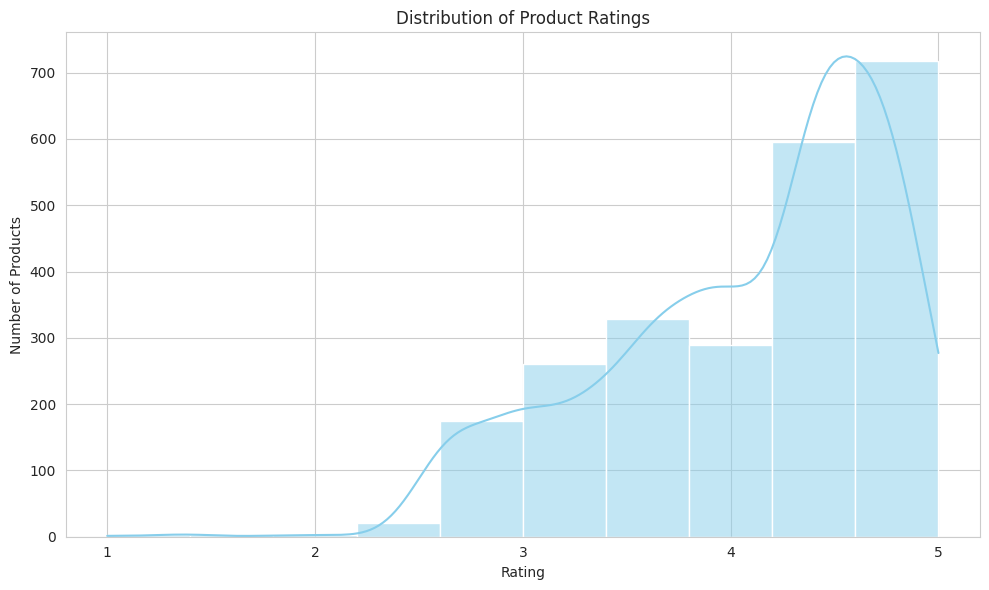

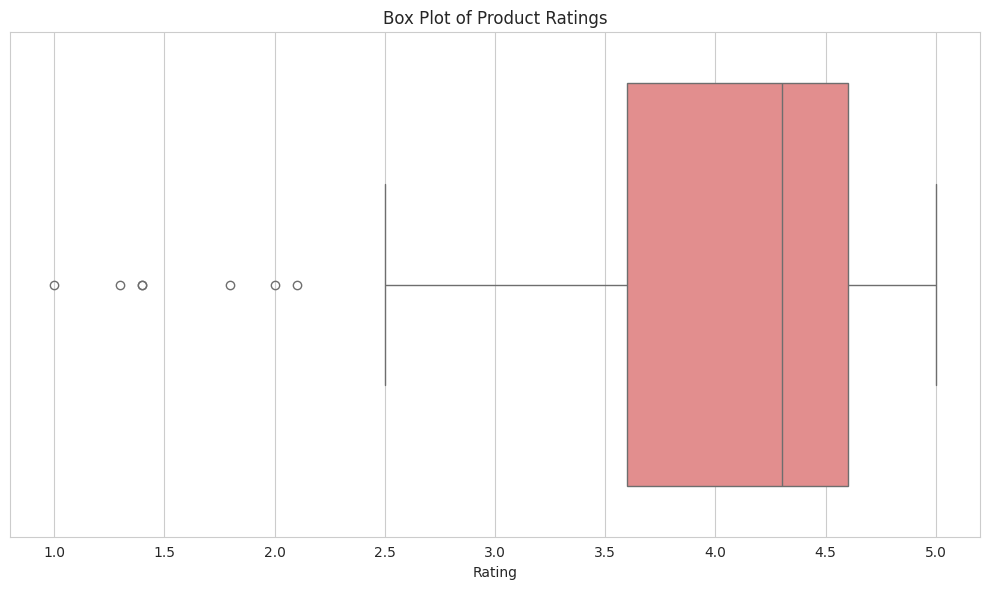

In [ ]:
# Plotting the distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(df_csv['rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.xticks(range(1, 6)) # Assuming ratings are typically 1-5
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_csv['rating'], color='lightcoral')
plt.title('Box Plot of Product Ratings')
plt.xlabel('Rating')
plt.tight_layout()
plt.show()

### 2. Which products have the highest visibility_score?

In [ ]:
# Sort products by 'popularity_score' (using it as a proxy for visibility_score) in descending order
highest_visibility_products = df_csv.sort_values(by='popularity_score', ascending=False)

print("Products with the Highest Visibility Score (Top 20):")
display(highest_visibility_products[['title', 'brand', 'platform', 'popularity_score', 'rating', 'price']].head(20))

Products with the Highest Visibility Score (Top 20):


,title,brand,platform,popularity_score,rating,price
1229,Samsung Galaxy S25 FE,Samsung,Walmart - Creo Distributions LLC,66.838589,4.7,425.00
1292,Samsung Galaxy S25 FE,Samsung,Best Buy,66.838589,4.7,649.99
1309,Samsung Galaxy S25 FE,Samsung,Best Buy,66.838589,4.7,649.99
1239,Samsung Galaxy S25 Ultra,Samsung,Walmart - Networkstore,66.683868,4.8,714.97
1322,Samsung Galaxy S25 Ultra,Samsung,Walmart - Networkstore,66.683868,4.8,714.97
1264,Samsung Galaxy S25 Edge,Samsung,AT&T,64.463278,4.8,15.99
1223,Samsung Galaxy S25 Edge,Samsung,Boost Mobile,64.463278,4.8,1099.99
1303,Samsung Galaxy S25 Edge,Samsung,Boost Mobile,64.463278,4.8,1099.99
1267,Samsung Galaxy S26 Ultra,Samsung,AT&T,63.616288,4.8,36.12
1224,Samsung Galaxy S26 Ultra,Samsung,AT&T,63.616288,4.8,36.12


### 3. Is there a relationship between rating and visibility_score?

Correlation between Rating and Visibility Score: 0.64


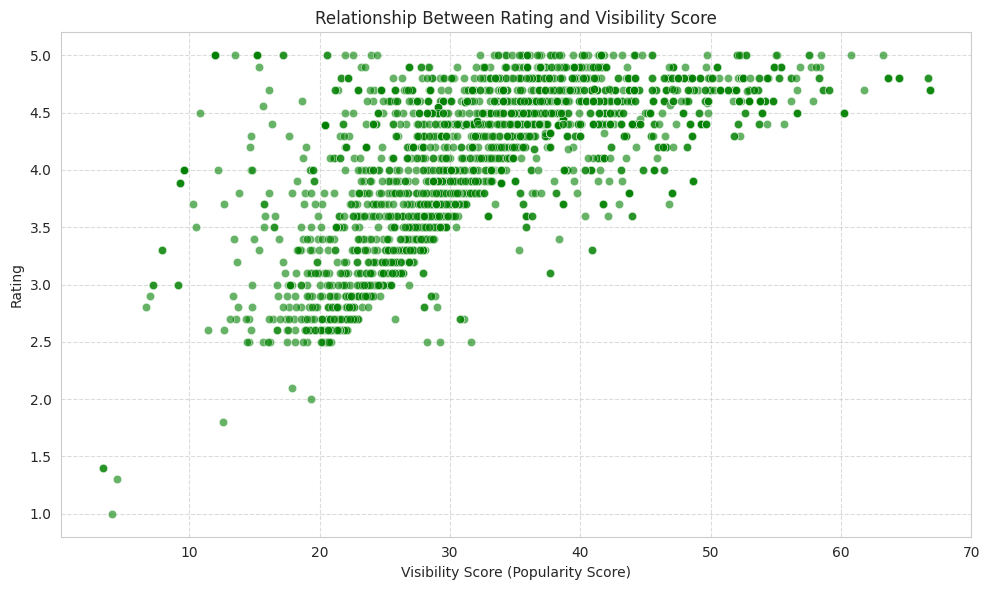

In [ ]:
# Calculate the correlation between rating and popularity_score
correlation_rating_visibility = df_csv['rating'].corr(df_csv['popularity_score'])
print(f"Correlation between Rating and Visibility Score: {correlation_rating_visibility:.2f}")

# Visualize the relationship using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='popularity_score', y='rating', data=df_csv, alpha=0.6, color='green')
plt.title('Relationship Between Rating and Visibility Score')
plt.xlabel('Visibility Score (Popularity Score)')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. Do products with higher reviews rank better?

Correlation between Reviews and Rating: 0.12


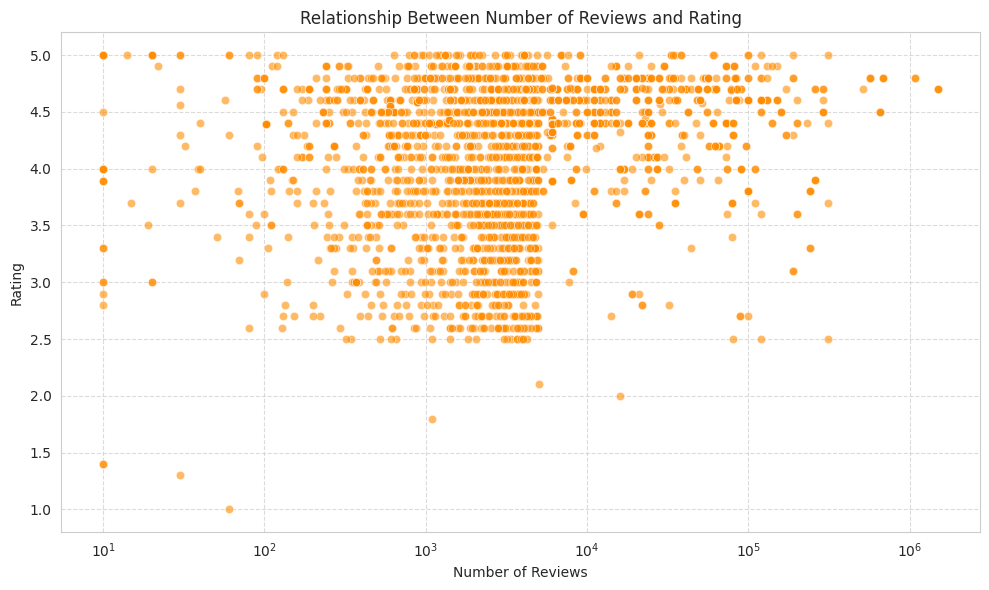

In [ ]:
# Calculate the correlation between reviews and rating
correlation_reviews_rating = df_csv['reviews'].corr(df_csv['rating'])
print(f"Correlation between Reviews and Rating: {correlation_reviews_rating:.2f}")

# Visualize the relationship using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='reviews', y='rating', data=df_csv, alpha=0.6, color='darkorange')
plt.title('Relationship Between Number of Reviews and Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.xscale('log') # Use log scale for reviews if there's a wide range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Which combination of factors (price, rating, reviews) influences top-ranking products?

Number of top-ranking products (rating >= 4.5): 890

Average Price for Top-Ranking Products: 9970.94
Average Number of Reviews for Top-Ranking Products: 33454.03
Average Visibility Score for Top-Ranking Products: 39.19

Overall Average Price: 16639.26
Overall Average Number of Reviews: 18966.05
Overall Average Visibility Score: 32.86


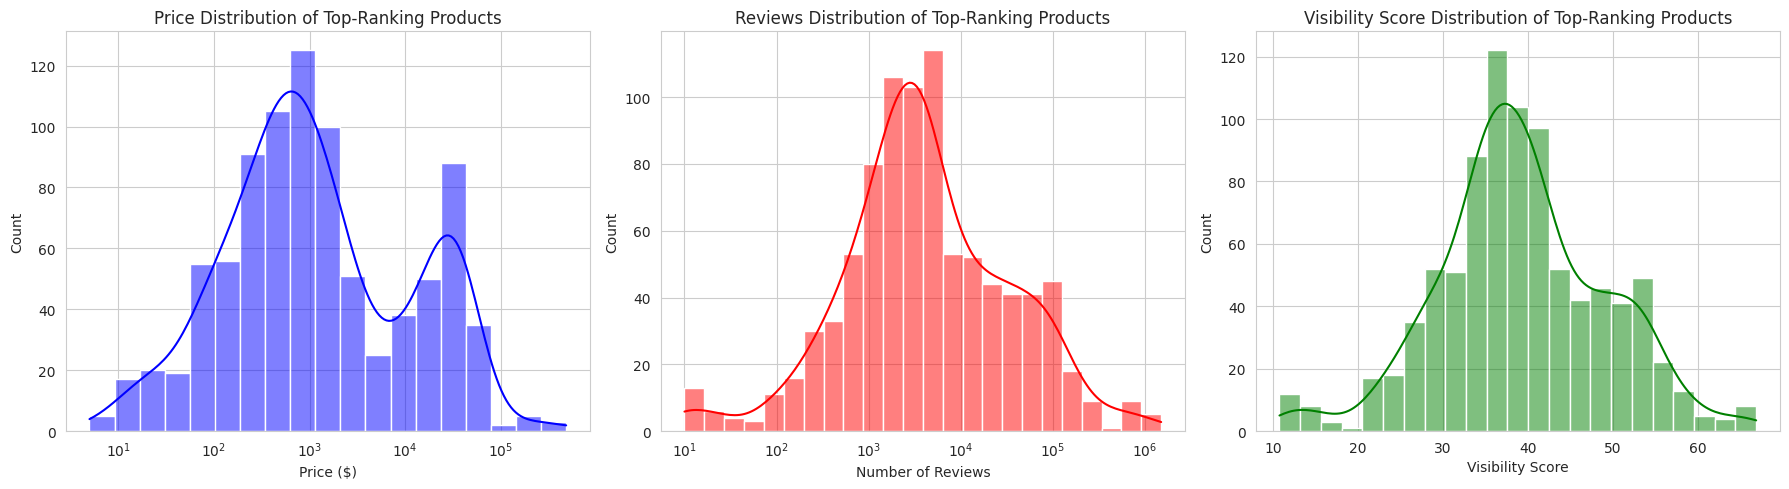

In [ ]:
# Define 'top-ranking products' as those with a rating of 4.5 or higher
top_ranking_products = df_csv[df_csv['rating'] >= 4.5]

print(f"Number of top-ranking products (rating >= 4.5): {len(top_ranking_products)}")

if not top_ranking_products.empty:
    # Analyze average price, reviews, and popularity score for top-ranking products
    avg_price_top_ranking = top_ranking_products['price'].mean()
    avg_reviews_top_ranking = top_ranking_products['reviews'].mean()
    avg_popularity_top_ranking = top_ranking_products['popularity_score'].mean()

    print(f"\nAverage Price for Top-Ranking Products: {avg_price_top_ranking:.2f}")
    print(f"Average Number of Reviews for Top-Ranking Products: {avg_reviews_top_ranking:.2f}")
    print(f"Average Visibility Score for Top-Ranking Products: {avg_popularity_top_ranking:.2f}")

    # Compare with overall averages
    overall_avg_price = df_csv['price'].mean()
    overall_avg_reviews = df_csv['reviews'].mean()
    overall_avg_popularity = df_csv['popularity_score'].mean()

    print(f"\nOverall Average Price: {overall_avg_price:.2f}")
    print(f"Overall Average Number of Reviews: {overall_avg_reviews:.2f}")
    print(f"Overall Average Visibility Score: {overall_avg_popularity:.2f}")

    # Visualize the distribution of these factors for top-ranking products
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(top_ranking_products['price'], ax=axes[0], kde=True, color='blue', log_scale=True)
    axes[0].set_title('Price Distribution of Top-Ranking Products')
    axes[0].set_xlabel('Price ($)')

    sns.histplot(top_ranking_products['reviews'], ax=axes[1], kde=True, color='red', log_scale=True)
    axes[1].set_title('Reviews Distribution of Top-Ranking Products')
    axes[1].set_xlabel('Number of Reviews')

    sns.histplot(top_ranking_products['popularity_score'], ax=axes[2], kde=True, color='green')
    axes[2].set_title('Visibility Score Distribution of Top-Ranking Products')
    axes[2].set_xlabel('Visibility Score')

    plt.tight_layout()
    plt.show()

else:
    print("No top-ranking products found based on the defined criteria.")

In [ ]:
import numpy as np
df_analysis = df_csv.copy()

df_analysis['ranking_group'] = pd.cut(
    df_analysis['rating'],
    bins=[-np.inf, 4.0, 4.5, np.inf],
    labels=[
        'Low-Rated',
        'Good-Rated',
        'Top-Rated'
    ],
    right=False
)

In [ ]:
comparison = (
    df_analysis.groupby('ranking_group', observed=True)
    .agg(
        product_count=('title', 'size'),

        average_price=('price', 'mean'),
        median_price=('price', 'median'),
        price_std=('price', 'std'),
        minimum_price=('price', 'min'),
        price_q1=('price', lambda x: x.quantile(0.25)),
        price_q3=('price', lambda x: x.quantile(0.75)),
        maximum_price=('price', 'max'),

        average_reviews=('reviews', 'mean'),
        median_reviews=('reviews', 'median'),
        reviews_std=('reviews', 'std'),
        minimum_reviews=('reviews', 'min'),
        reviews_q1=('reviews', lambda x: x.quantile(0.25)),
        reviews_q3=('reviews', lambda x: x.quantile(0.75)),
        maximum_reviews=('reviews', 'max'),
        total_reviews=('reviews', 'sum')
    )
    .round(2)
    .reset_index()
)

display(comparison)


,ranking_group,product_count,average_price,median_price,price_std,minimum_price,price_q1,price_q3,maximum_price,average_reviews,median_reviews,reviews_std,minimum_reviews,reviews_q1,reviews_q3,maximum_reviews,total_reviews
0,Low-Rated,888,24096.40,17882.0,41584.95,9.99,3567.00,32810.00,498050.0,8717.69,2525.5,32627.45,10,1096.75,3890.25,310000,7741305
1,Good-Rated,614,15520.13,1499.0,42783.37,5.99,349.00,21315.25,461640.0,12787.27,3453.5,29600.98,10,1090.00,7495.00,310000,7851385
2,Top-Rated,890,9970.94,849.0,31855.63,4.99,294.46,6298.25,482890.0,33454.03,3620.0,124703.54,10,1315.25,15000.00,1500000,29774091


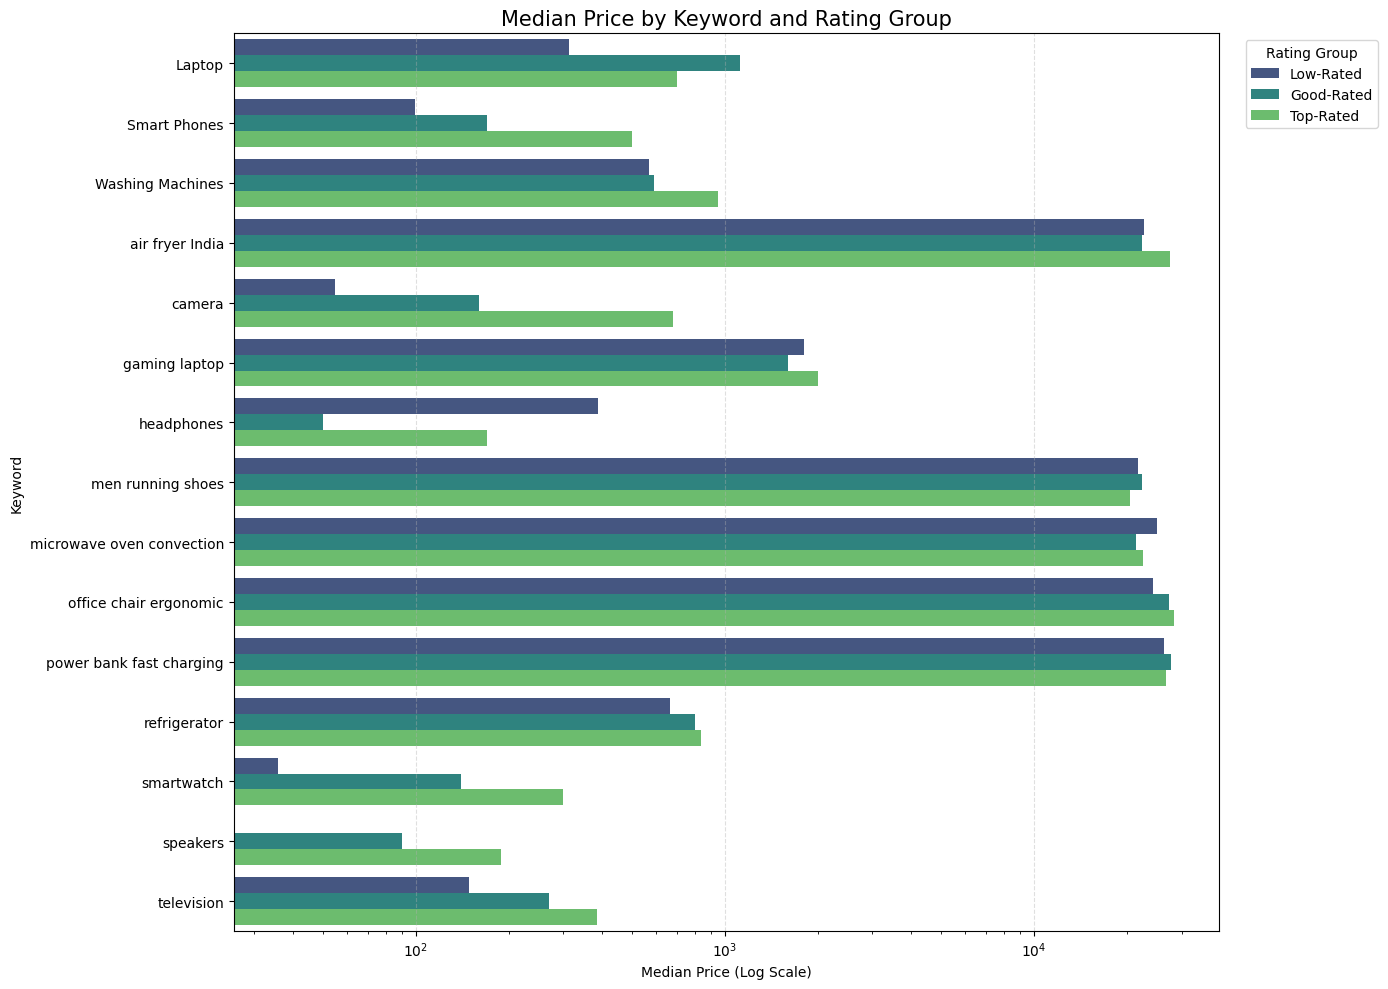

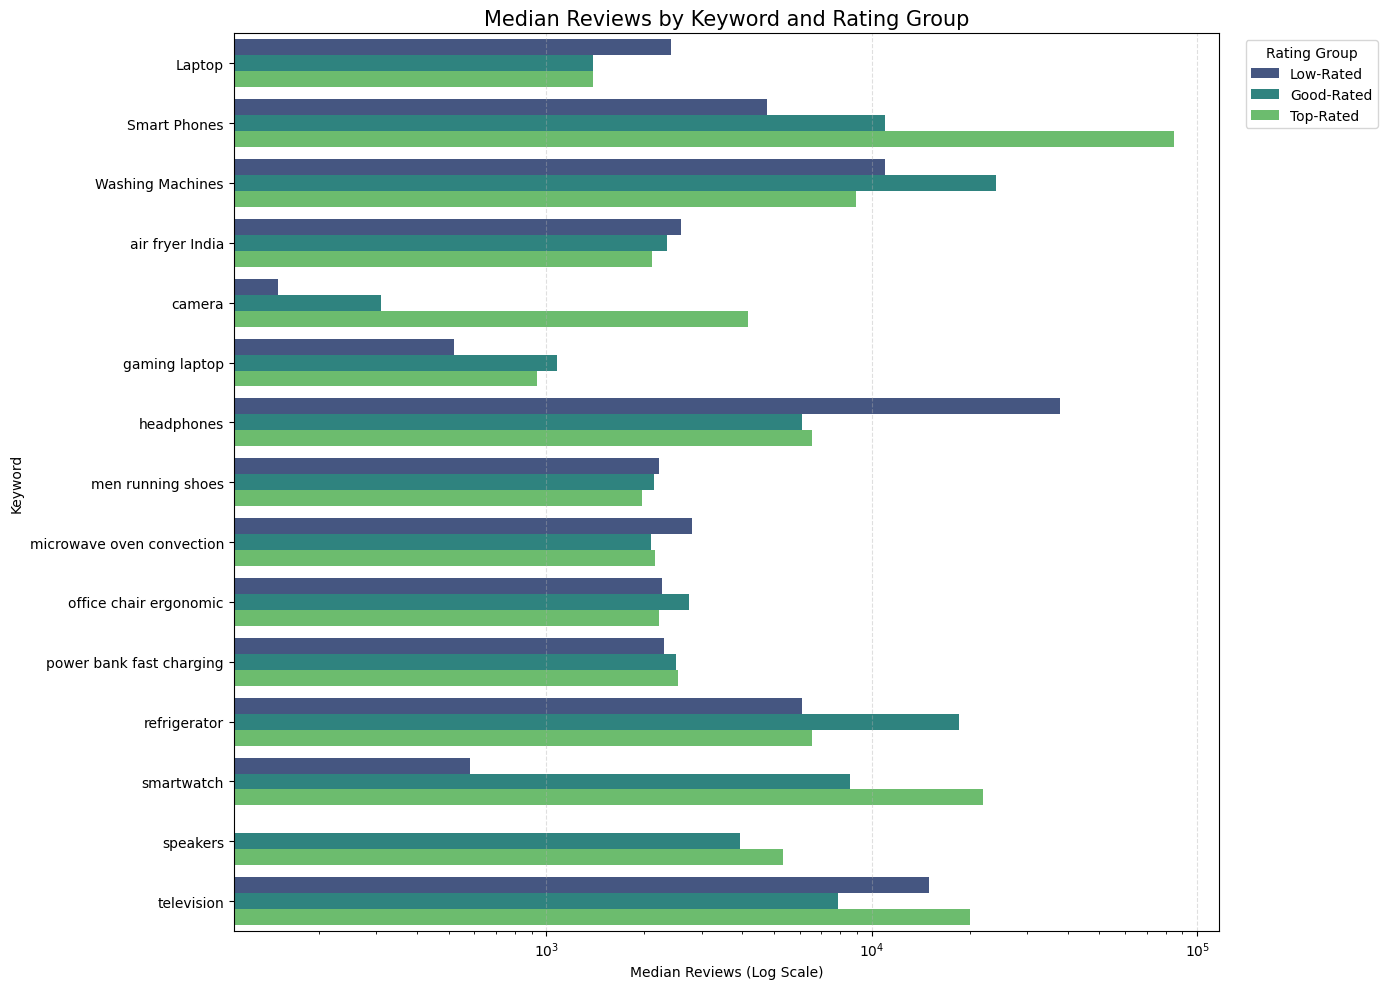

In [ ]:
plot_info = {
    'median_price': 'Median Price',
    'median_reviews': 'Median Reviews'
}

for col, label in plot_info.items():

    plt.figure(figsize=(14, 10))

    sns.barplot(
        data=keyword_comparison,
        x=col,
        y='keyword',
        hue='ranking_group',
        hue_order=ranking_order,
        palette='viridis'
    )

    # Apply log scale for both because both are skewed
    plt.xscale('log')

    plt.title(
        f'{label} by Keyword and Rating Group',
        fontsize=15
    )

    plt.xlabel(f'{label} (Log Scale)')
    plt.ylabel('Keyword')

    plt.legend(
        title='Rating Group',
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()

In [ ]:
group_distribution = (
    df_analysis['ranking_group']
    .value_counts()
    .rename_axis('Ranking Group')
    .reset_index(name='Product Count')
)

group_distribution['Percentage'] = (
    group_distribution['Product Count']
    / group_distribution['Product Count'].sum()
    * 100
).round(2)

display(group_distribution)

,Ranking Group,Product Count,Percentage
0,Top-Rated,890,37.21
1,Low-Rated,888,37.12
2,Good-Rated,614,25.67


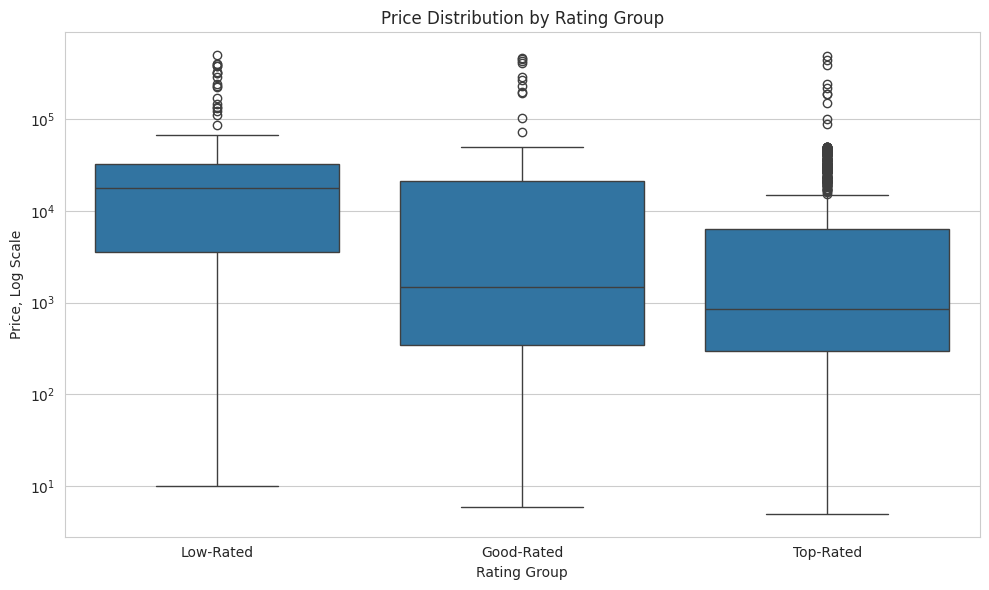

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x='ranking_group',
    y='price',
    order=['Low-Rated', 'Good-Rated', 'Top-Rated']
)

plt.yscale('log')
plt.title('Price Distribution by Rating Group')
plt.xlabel('Rating Group')
plt.ylabel('Price, Log Scale')
plt.tight_layout()
plt.show()

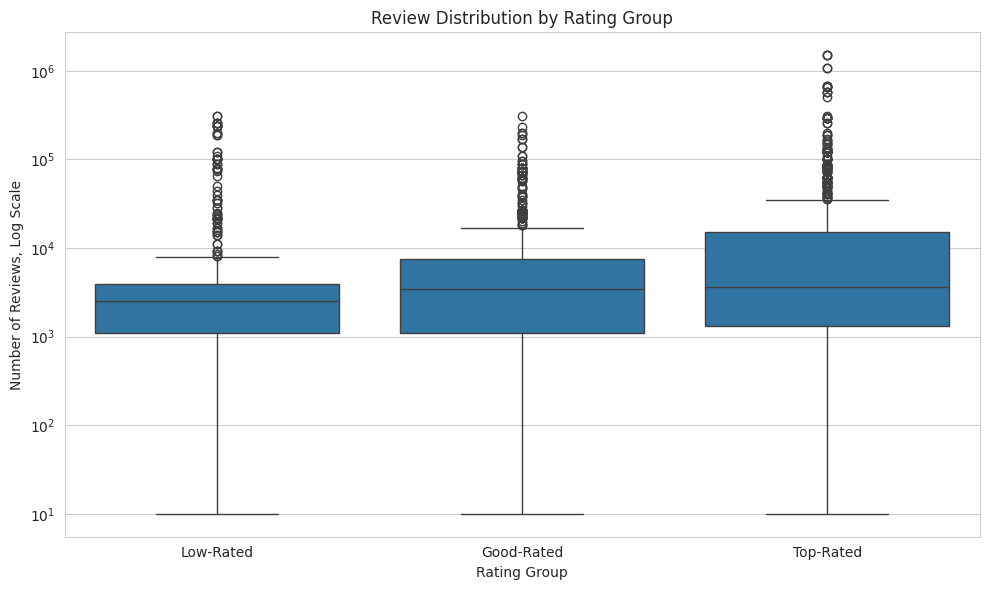

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x='ranking_group',
    y='reviews',
    order=['Low-Rated', 'Good-Rated', 'Top-Rated']
)

plt.yscale('log')
plt.title('Review Distribution by Rating Group')
plt.xlabel('Rating Group')
plt.ylabel('Number of Reviews, Log Scale')
plt.tight_layout()
plt.show()

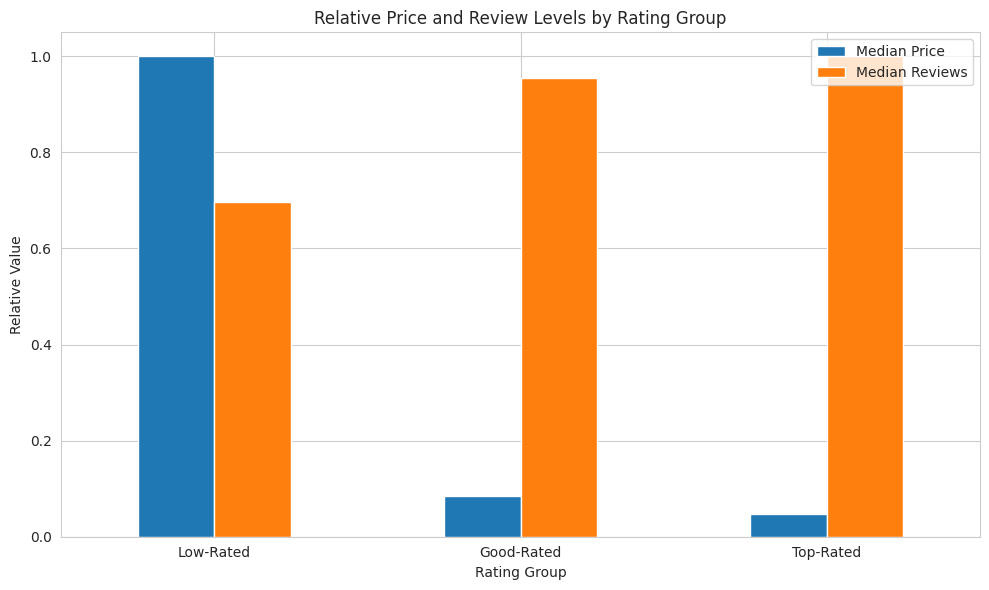

In [ ]:
median_comparison = (
    df_analysis.groupby('ranking_group', observed=True)
    .agg(
        median_price=('price', 'median'),
        median_reviews=('reviews', 'median')
    )
)

normalized_comparison = (
    median_comparison
    / median_comparison.max()
)

normalized_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Relative Price and Review Levels by Rating Group')
plt.xlabel('Rating Group')
plt.ylabel('Relative Value')
plt.xticks(rotation=0)
plt.legend(['Median Price', 'Median Reviews'])
plt.tight_layout()
plt.show()

Top-Rated products are not generally the most expensive products. They have the lowest mean and lowest median prices but the highest median review count and substantially greater upper-end review engagement. This suggests that affordable pricing combined with strong customer engagement is more closely associated with Top-Rated products than premium pricing.

**Top-Rated≈lower typical price+higher review engagement**